In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from scipy.sparse import csr_matrix

sc.settings.n_jobs = 8
sc.set_figure_params(figsize=(5,5), dpi_save=300, dpi=100, frameon=False)
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams["font.family"] = "Arial"
plt.rcParams['axes.grid'] = False
%config InlineBackend.figure_format = 'retina'

In [2]:
import scFates as scf

In [3]:
adata = sc.read_h5ad('./Results_h5ad/07_neuron_liu_dev_scenic.h5ad')

In [4]:
adata_exp = sc.read_h5ad('./Results_h5ad/07_neuron_liu_dev.h5ad')[adata.obs_names].copy()

In [ ]:
sc.pl.umap(adata_exp, color='leiden_sub', save='_Liu_clean.pdf')

In [5]:
# adata.obsp = adata_exp.obsp.copy()

In [6]:
adata = adata[~adata.obs.leiden.isin(['6','8'])].copy()

In [9]:
adata_exp = adata_exp[~adata_exp.obs.leiden.isin(['6','8'])].copy()

# Core

In [183]:
adata_core = adata[adata.obs.leiden.isin(['0','3','7'])].copy()

In [184]:
import palantir
pca_projections = pd.DataFrame(adata_core.obsm["X_pca"],index=adata_core.obs_names)
dm_res = palantir.utils.run_diffusion_maps(pca_projections, knn=30)
ms_data = palantir.utils.determine_multiscale_space(dm_res,n_eigs=None)
adata_core.obsm["X_palantir"]=ms_data.values
# sc.pp.neighbors(adata_core,n_neighbors=50,use_rep="X_palantir")
# adata_core.obsm["X_pca2d"]=adata_core.obsm["X_pca"][:,:2]
# sc.tl.umap(adata_core,init_pos='X_pca2d')

inferring a principal tree --> parameters used 
    100 principal points, sigma = 1, lambda = 0.1, metric = euclidean
    fitting:   0%|          | 0/1000 [00:00<?, ?it/s]
    converged
    finished (0:00:00) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.


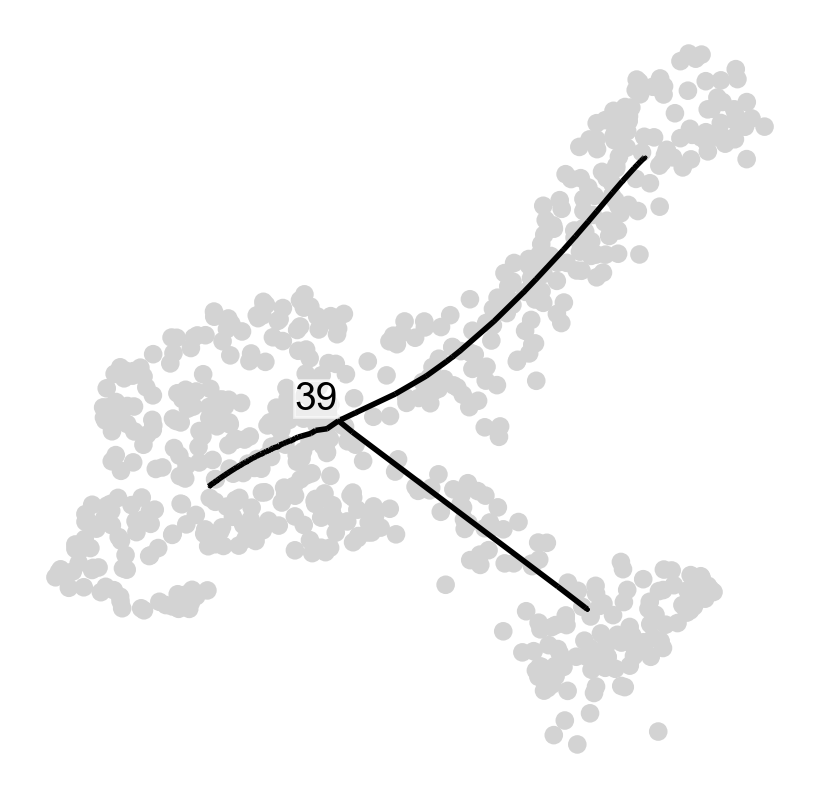

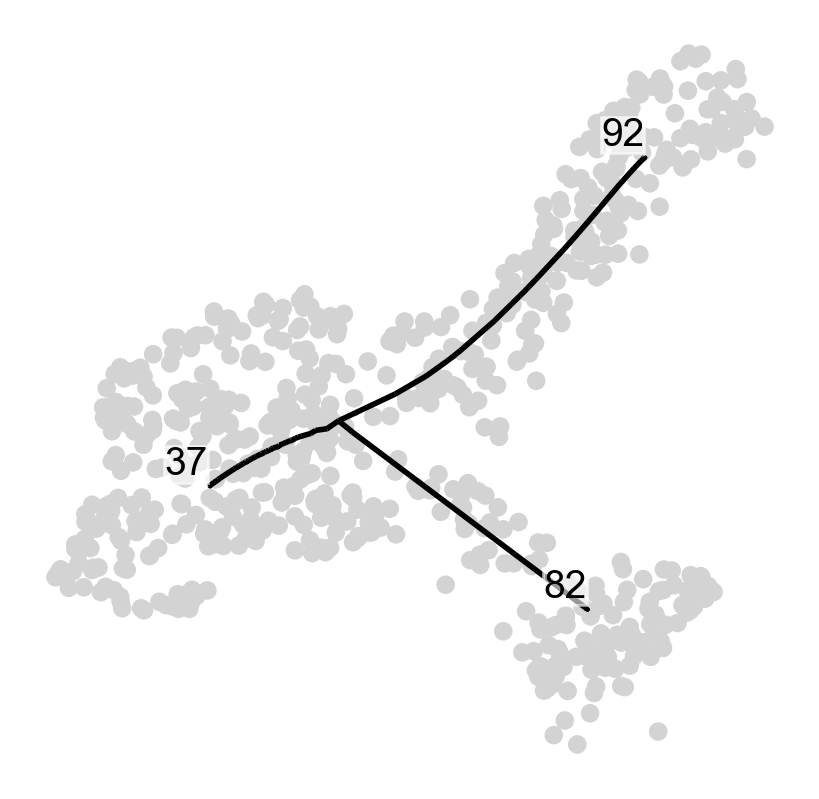

In [185]:
scf.tl.tree(adata_core,method="ppt",Nodes=100,use_rep="umap",
            device="cpu",seed=42,ppt_lambda=0.1,ppt_sigma=1,ppt_nsteps=1000)
scf.pl.graph(adata_core, forks=True, tips=False, size_nodes=.1)
scf.pl.graph(adata_core, forks=False, tips=True, size_nodes=.1)

In [186]:
scf.tl.root(adata_core,37)
scf.tl.pseudotime(adata_core,n_jobs=6,n_map=100,seed=42)

node 37 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.
projecting cells onto the principal graph
    mappings: 100%|██████████| 100/100 [00:11<00:00,  8.77it/s]
    finished (0:00:11) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


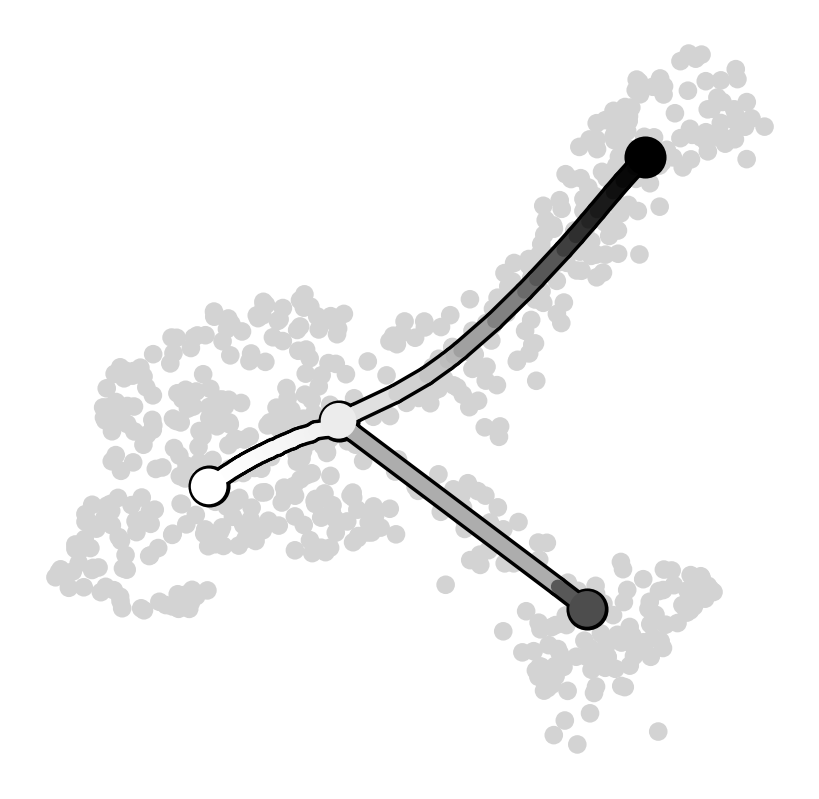

In [215]:
scf.pl.trajectory(adata_core, save='_pseudotime_core.pdf', cmap_seg='Greys')

In [189]:
milestones_mapper = {'37': 'Root','39': 'BifA','82': 'B','92': 'A'}

In [190]:
scf.tl.rename_milestones(adata_core,milestones_mapper)

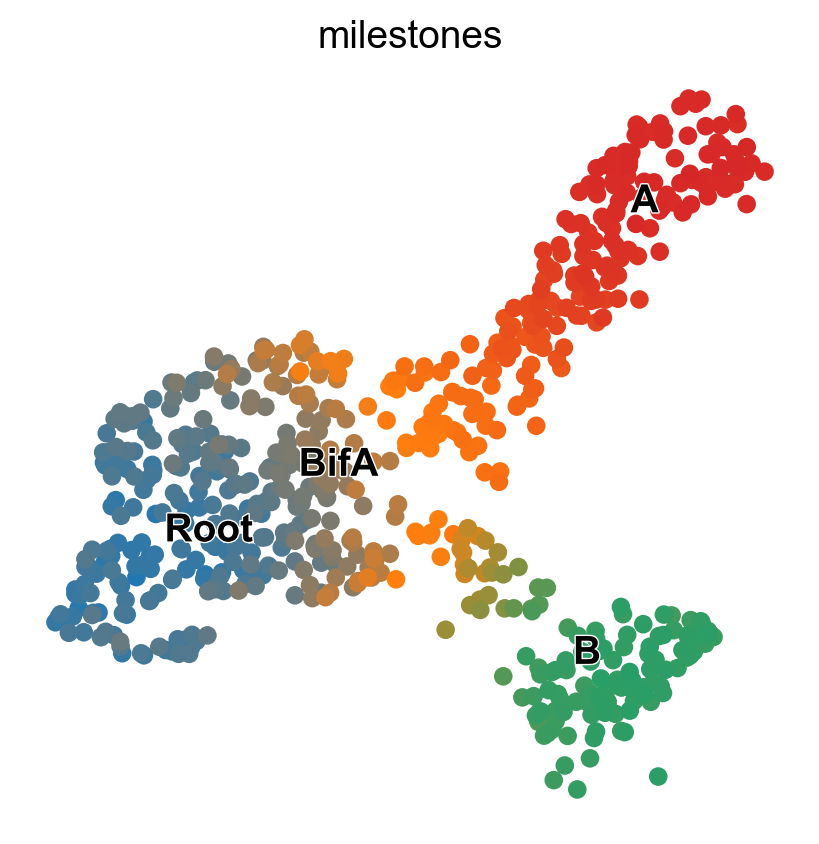

In [202]:
scf.pl.milestones(adata_core, annotate=True, save='_milestones_core.pdf')

In [84]:
scf.tl.dendrogram(adata_core)
plt.close()

Generating dendrogram of tree
    finished (0:00:00) --> added 
    .obsm['X_dendro'], new embedding generated.
    .uns['dendro_segments'] tree segments used for plotting.


In [85]:
scf.tl.test_association(adata_core,n_jobs=6,fdr_cut=0.05,A_cut=0.0001)
# adata_core.uns["pseudotime_list"][str(0)]=adata_core.uns["pseudotime_list"][str(0)].loc[adata_core.obs_names]
scf.tl.fit(adata_core,n_jobs=6)

test features for association with the trajectory
    single mapping :   0%|          | 0/547 [00:00<?, ?it/s]

    single mapping : 100%|██████████| 547/547 [00:02<00:00, 209.22it/s]
    found 215 significant features (0:00:02) --> added
    .var['p_val'] values from statistical test.
    .var['fdr'] corrected values from multiple testing.
    .var['st'] proportion of mapping in which feature is significant.
    .var['A'] amplitue of change of tested feature.
    .var['signi'] feature is significantly changing along pseudotime.
    .uns['stat_assoc_list'] list of fitted features on the graph for all mappings.
fit features associated with the trajectory
    single mapping : 100%|██████████| 215/215 [00:01<00:00, 122.66it/s]
    finished (adata subsetted to keep only fitted features!) (0:00:02) --> added
    .layers['fitted'], fitted features on the trajectory for all mappings.
    .raw, unfiltered data.


In [87]:
milestones = ['B','A']

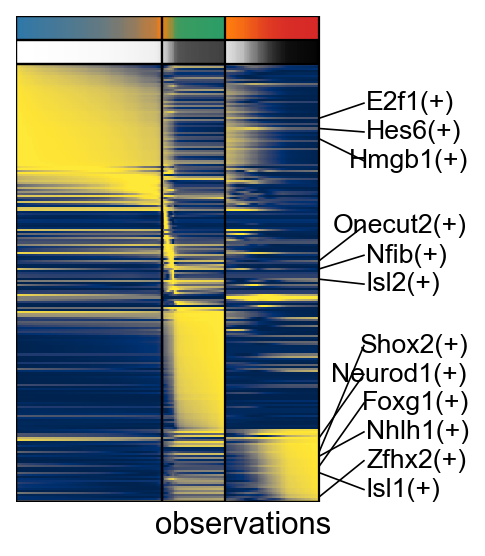

In [88]:
reg = scf.pl.trends(adata_core,root_milestone='Root',n_features=12,plot_emb=False,ordering="max",annot="milestones",
                    fig_heigth=20,ord_thre=.95,fontsize=12,return_genes=True,feature_cmap='cividis', pseudo_cmap='Greys')
plt.savefig("./figures/top12_trends_core.pdf",bbox_inches='tight', dpi=300)

In [89]:
for g in ['E2f1(+)','Neurod1(+)','Onecut2(+)']:
    ax=scf.pl.single_trend(adata_core,g,show=False,plot_emb='dendrogram',cmap_cells='cividis',cmap_seg='cividis', save=f"_{g.strip('(+)')}_trend_dendrogram.pdf")

# Branch A

In [192]:
adata_a = adata[adata.obs.leiden.isin(['0','1','2','3','5'])].copy()

In [193]:
import palantir
pca_projections = pd.DataFrame(adata_a.obsm["X_pca"],index=adata_a.obs_names)
dm_res = palantir.utils.run_diffusion_maps(pca_projections, knn=30)
ms_data = palantir.utils.determine_multiscale_space(dm_res,n_eigs=None)
adata_a.obsm["X_palantir"]=ms_data.values
# sc.pp.neighbors(adata_a,n_neighbors=50,use_rep="X_palantir")
# adata_a.obsm["X_pca2d"]=adata_a.obsm["X_pca"][:,:2]
# sc.tl.umap(adata_a,init_pos='X_pca2d')

inferring a principal tree --> parameters used 
    100 principal points, sigma = 1, lambda = 0.1, metric = euclidean
    fitting:   0%|          | 0/1000 [00:00<?, ?it/s]
    converged
    finished (0:00:00) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.


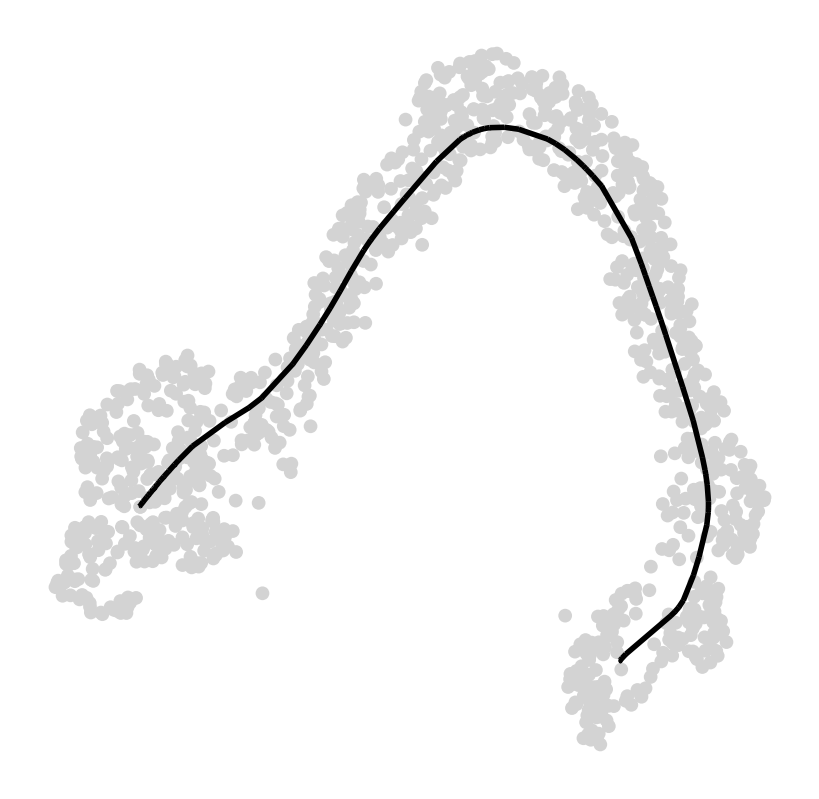

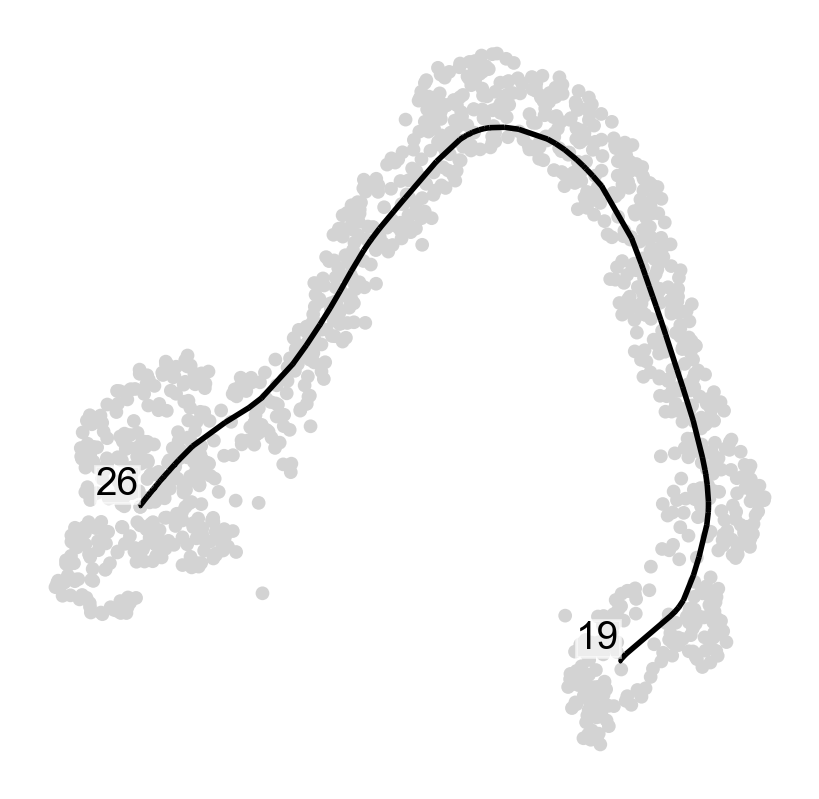

In [194]:
scf.tl.tree(adata_a,method="ppt",Nodes=100,use_rep="umap",
            device="cpu",seed=42,ppt_lambda=0.1,ppt_sigma=1,ppt_nsteps=1000)
scf.pl.graph(adata_a, forks=True, tips=False, size_nodes=.1)
scf.pl.graph(adata_a, forks=False, tips=True, size_nodes=.1)

In [195]:
scf.tl.root(adata_a,26)
scf.tl.pseudotime(adata_a,n_jobs=6,n_map=100,seed=42)

node 26 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.
projecting cells onto the principal graph
    mappings: 100%|██████████| 100/100 [00:05<00:00, 16.78it/s]
    finished (0:00:06) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


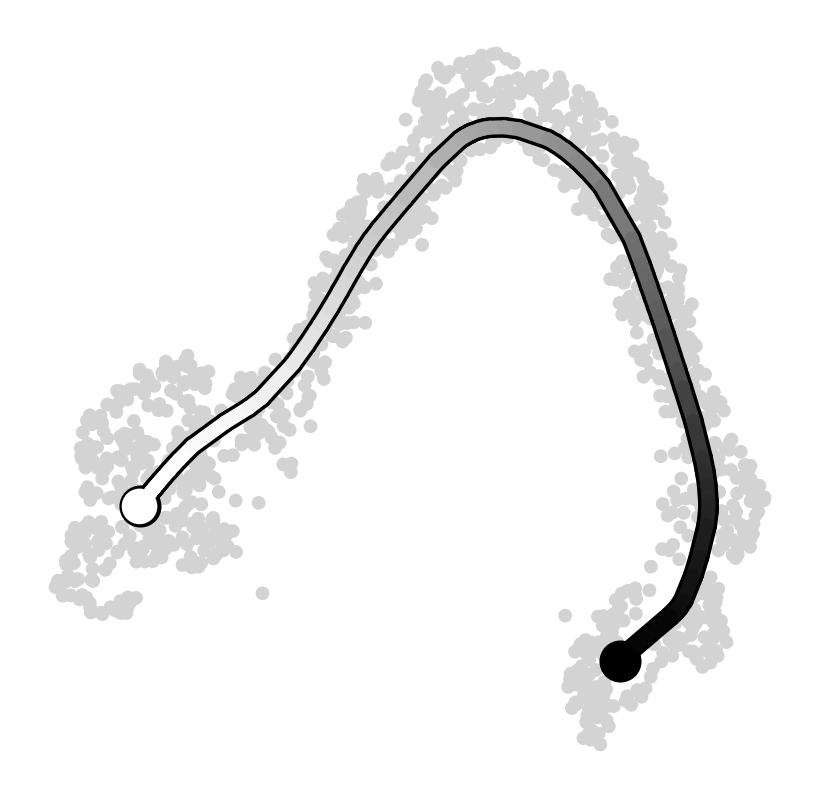

In [214]:
scf.pl.trajectory(adata_a, save='_pseudotime_branchA.pdf', cmap_seg='Greys')

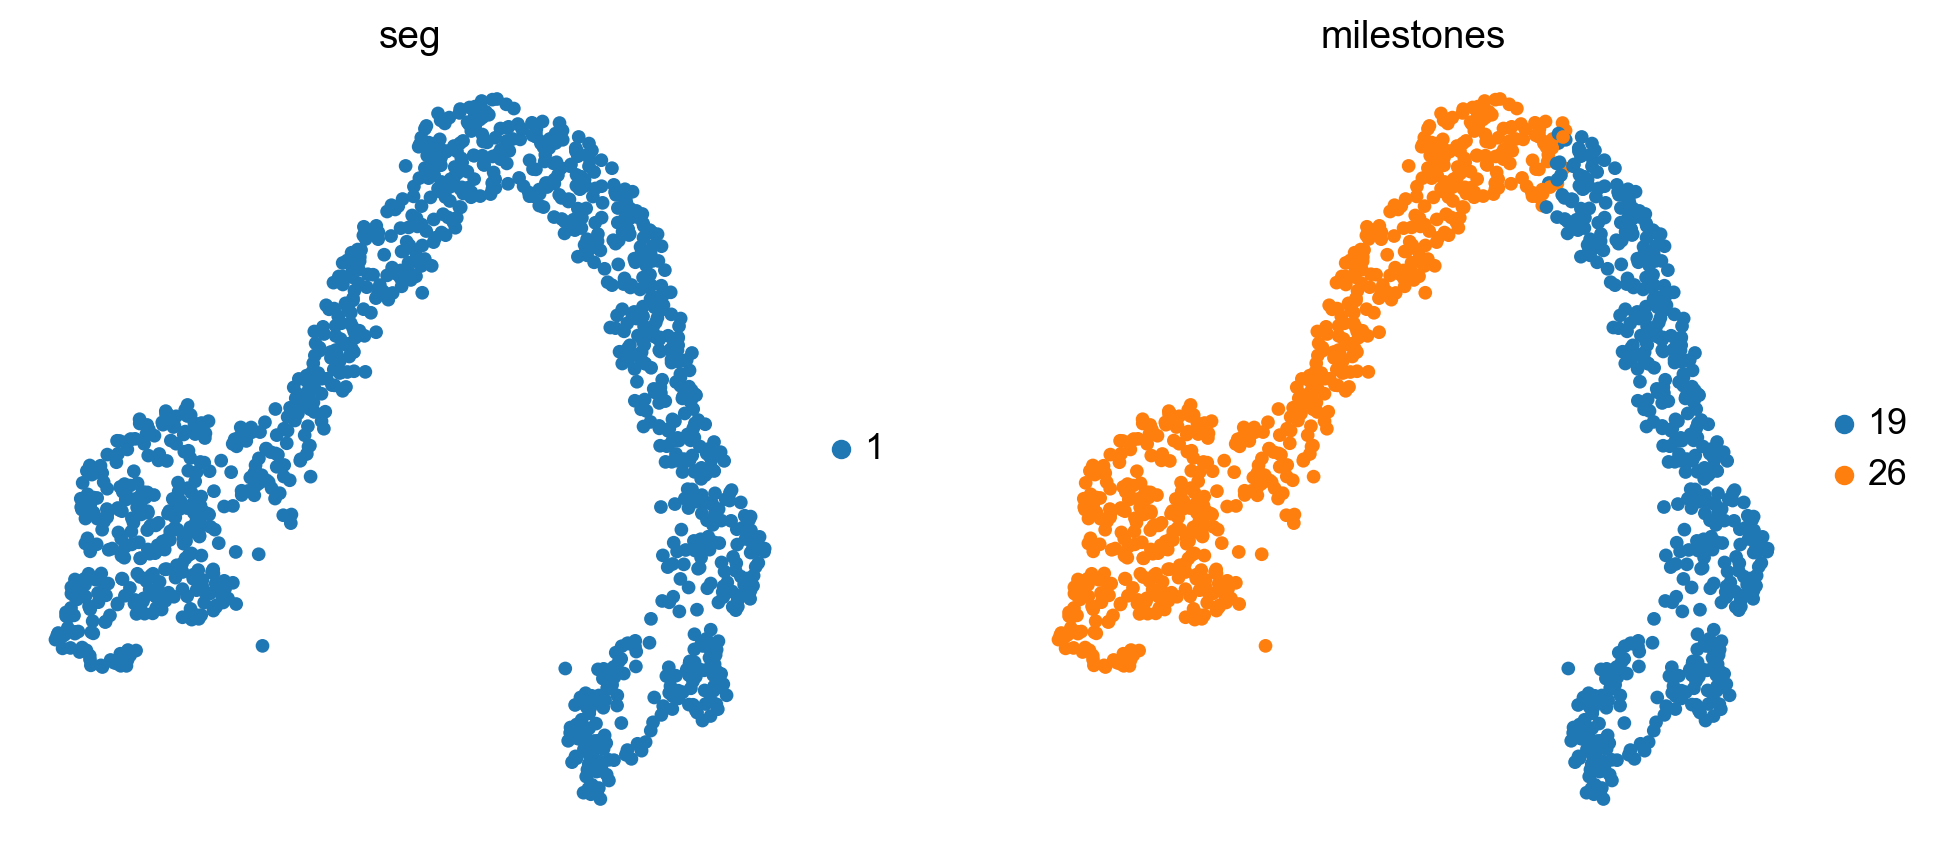

In [198]:
sc.pl.umap(adata_a, color=["seg","milestones"])

In [199]:
milestones_mapper = {'19': 'A','26': 'Root'}

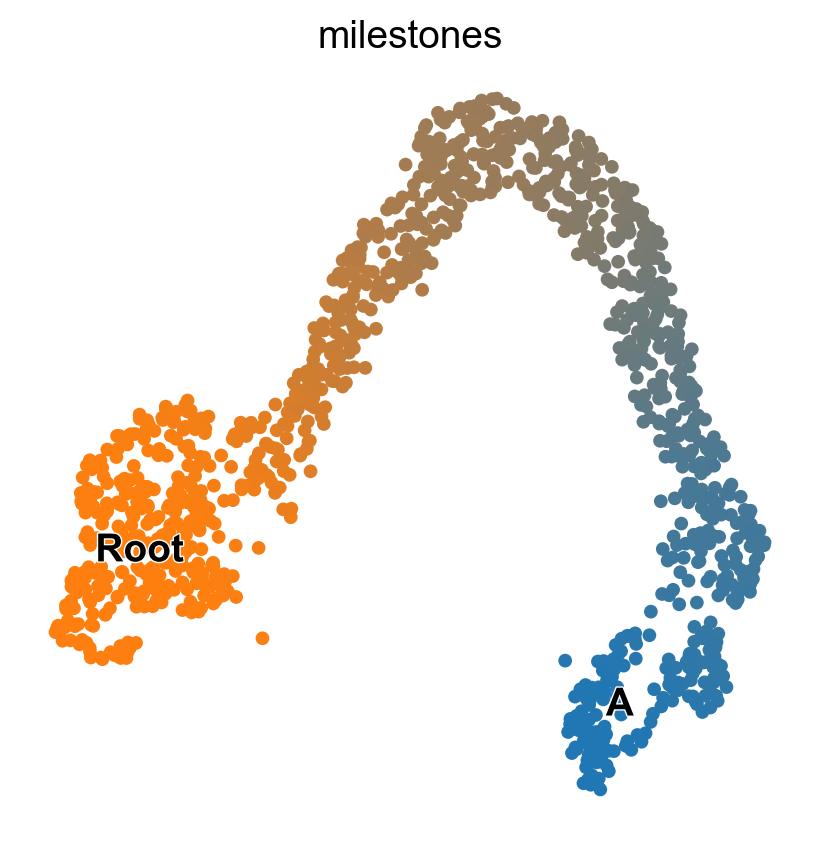

In [201]:
# scf.tl.rename_milestones(adata_a,milestones_mapper)
scf.pl.milestones(adata_a, annotate=True, save='_milestones_branchA.pdf')

Estimation of deviation from linearity
    cells on the bridge: 100%|██████████| 796/796 [00:00<00:00, 1701.11it/s]


/Users/pax/miniconda3/envs/scFates/lib/python3.11/site-packages/scFates/tools/linearity_deviation.py:144: RuntimeWarning: invalid value encountered in divide
  return rs.mean(axis=1) / X_all.std(axis=0)


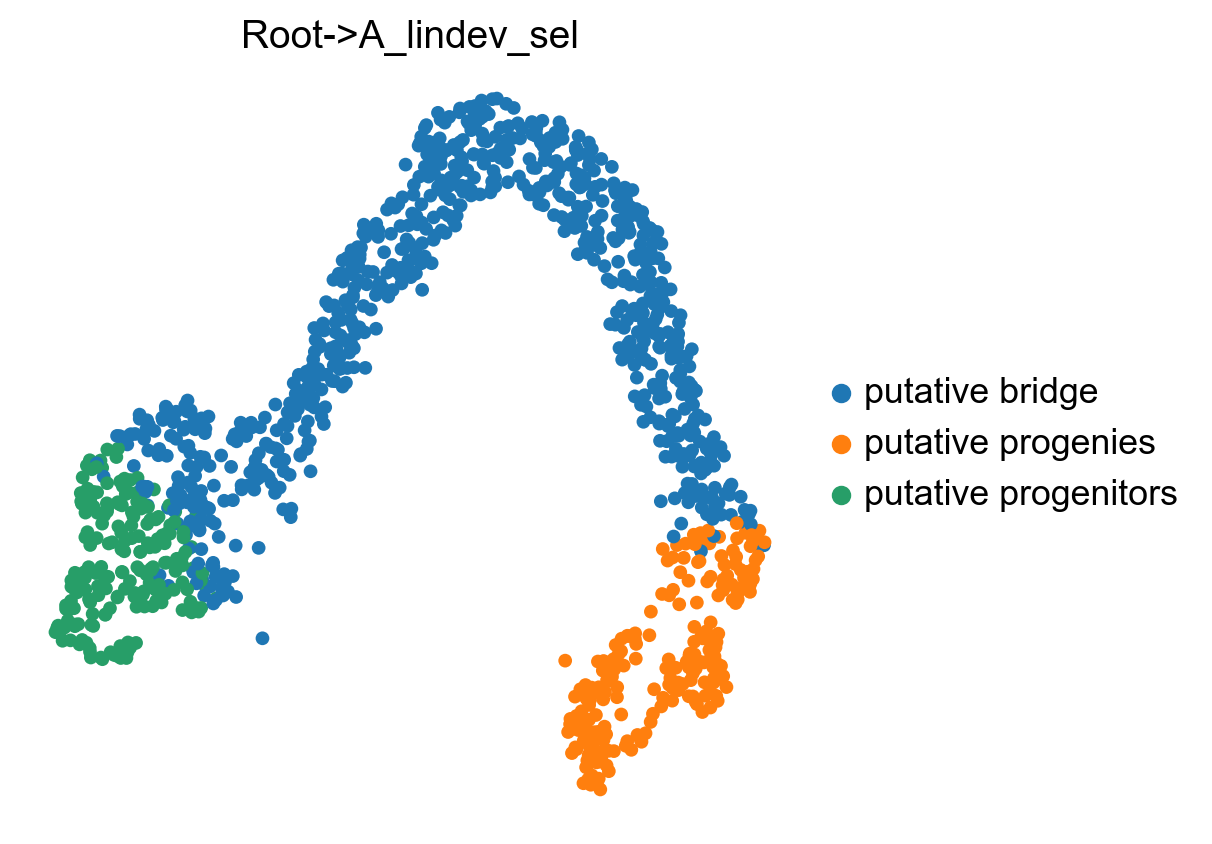

    finished (0:00:00) --> added 
    .var['Root->A_rss'], pearson residuals of the linear fit.
    .obs['Root->A_lindev_sel'], cell selections used for the test.


/Users/pax/miniconda3/envs/scFates/lib/python3.11/site-packages/scFates/tools/linearity_deviation.py:164: RuntimeWarning: Mean of empty slice
  adata.var[name + "_rss"] = np.nanmean(np.vstack(rss), axis=0)


<Figure size 500x500 with 0 Axes>

In [204]:
scf.tl.linearity_deviation(adata_a,
                           start_milestone="Root",
                           end_milestone="A",
                           n_jobs=6,plot=True,basis="umap")
plt.savefig('./figures/umap_branchA_stages.pdf')

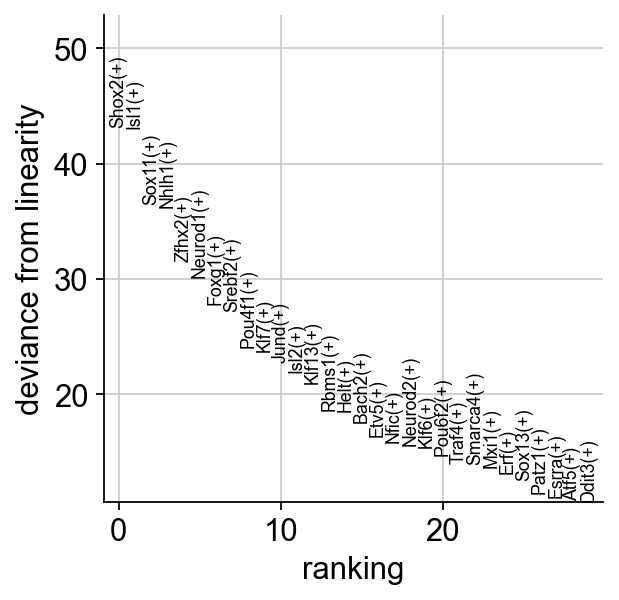

In [101]:
scf.pl.linearity_deviation(adata_a,
                           start_milestone="Root",
                           end_milestone="A")

In [ ]:
scf.tl.test_association(adata_a,n_jobs=6,A_cut=0.0025)
scf.tl.fit(adata_a,n_jobs=6)

test features for association with the trajectory
    single mapping : 100%|██████████| 547/547 [00:03<00:00, 153.79it/s]
    found 196 significant features (0:00:03) --> added
    .var['p_val'] values from statistical test.
    .var['fdr'] corrected values from multiple testing.
    .var['st'] proportion of mapping in which feature is significant.
    .var['A'] amplitue of change of tested feature.
    .var['signi'] feature is significantly changing along pseudotime.
    .uns['stat_assoc_list'] list of fitted features on the graph for all mappings.


In [108]:
scf.tl.cluster(adata_a,n_neighbors=100,metric="correlation")

Clustering features using fitted layer
    finished (0:00:00) --> added 
    .var['clusters'] identified modules.


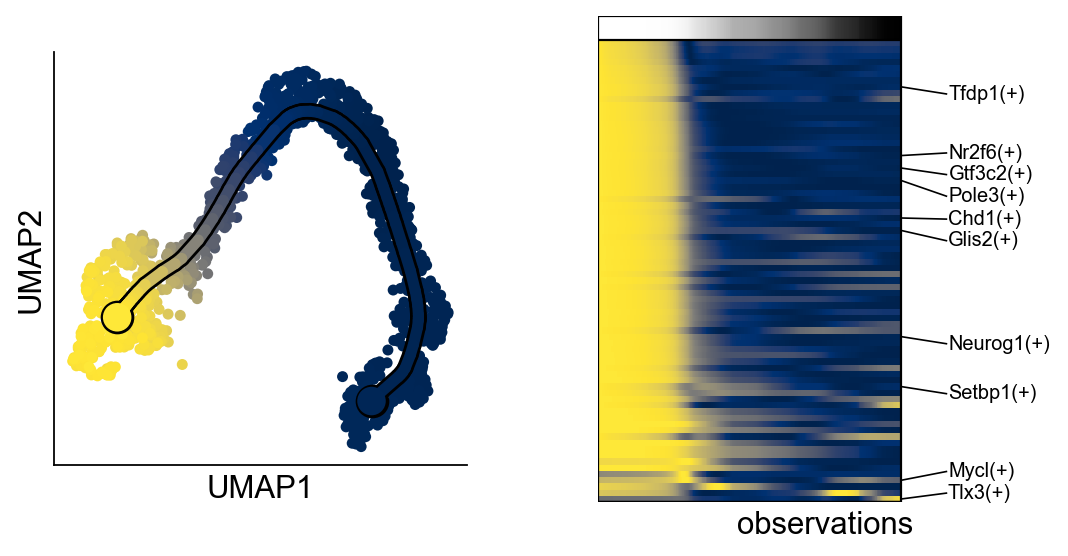

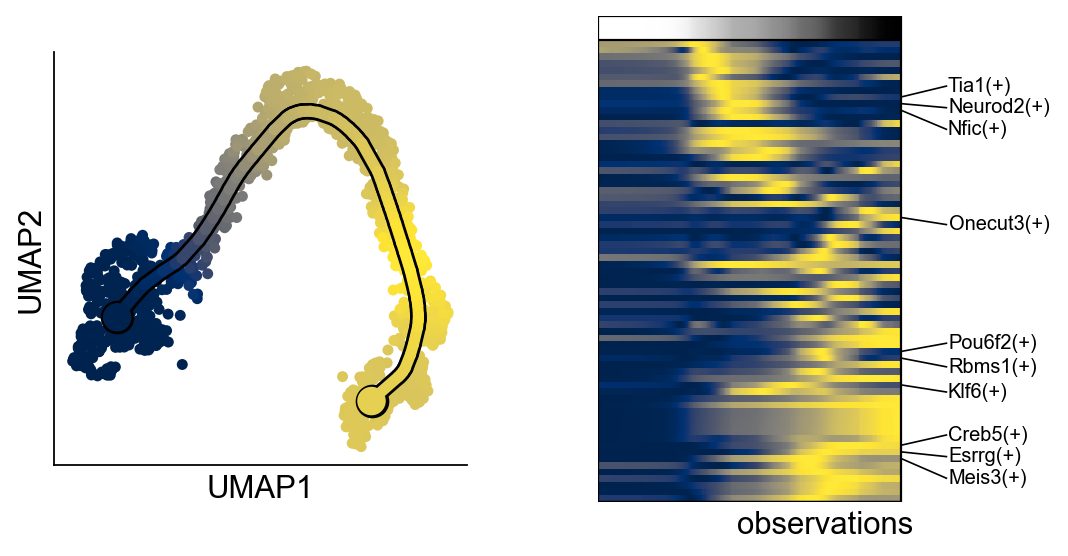

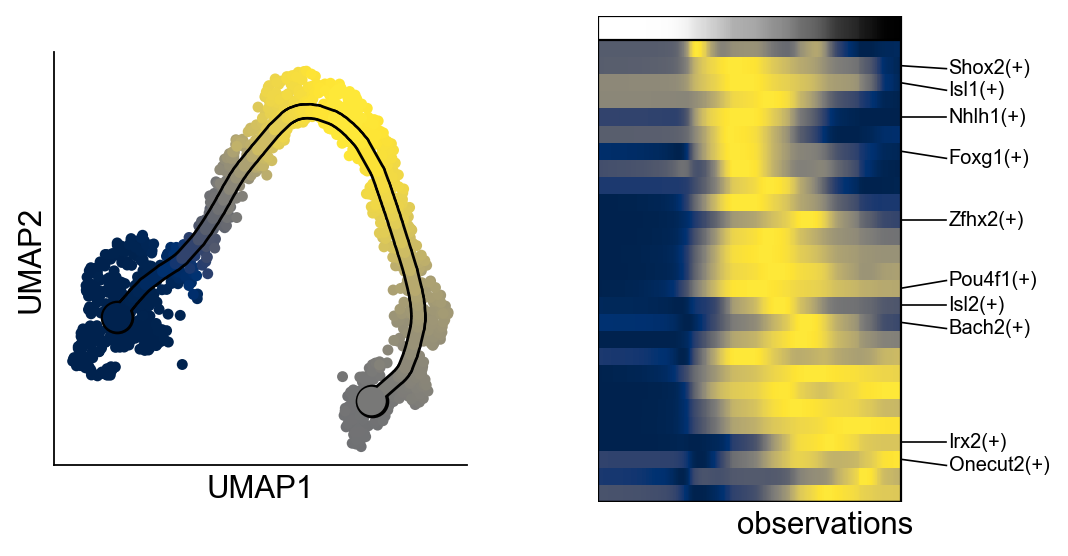

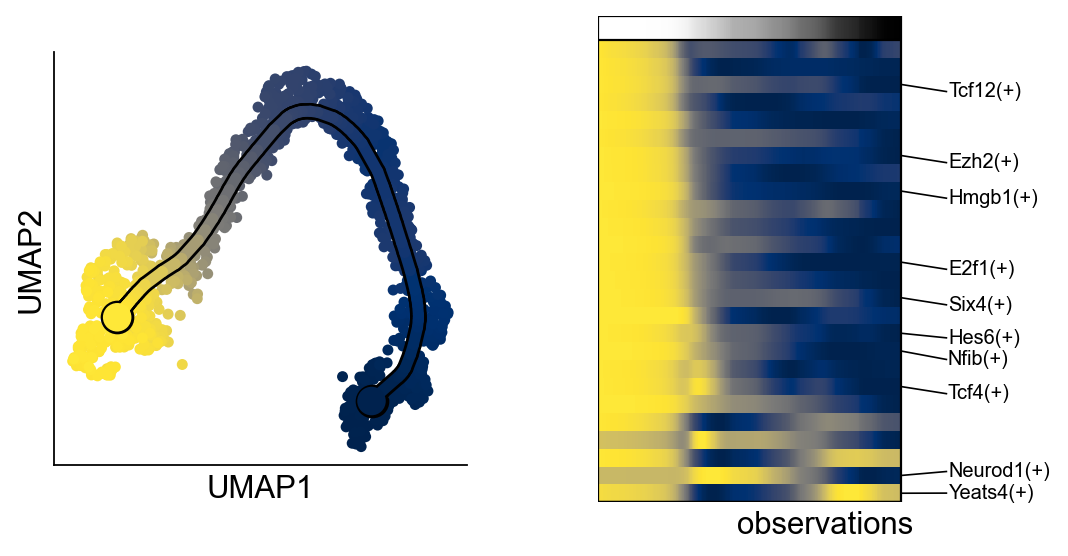

In [114]:
for c in adata_a.var["clusters"].cat.categories:
    scf.pl.trends(adata_a,features=adata_a.var_names[adata_a.var.clusters==c],basis="umap",feature_cmap='cividis',pseudo_cmap='Greys',save=f"_cluster{c}_branchA.pdf")

# Branch B

In [205]:
adata_b = adata[adata.obs.leiden.isin(['0','7','4'])].copy()

In [206]:
import palantir
pca_projections = pd.DataFrame(adata_b.obsm["X_pca"],index=adata_b.obs_names)
dm_res = palantir.utils.run_diffusion_maps(pca_projections, knn=30)
ms_data = palantir.utils.determine_multiscale_space(dm_res,n_eigs=None)
adata_b.obsm["X_palantir"]=ms_data.values
# sc.pp.neighbors(adata_b,n_neighbors=50,use_rep="X_palantir")
# adata_b.obsm["X_pca2d"]=adata_b.obsm["X_pca"][:,:2]
# sc.tl.umap(adata_b,init_pos='X_pca2d')

inferring a principal tree --> parameters used 
    100 principal points, sigma = 0.5, lambda = 1, metric = euclidean
    fitting:   4%|▍         | 42/1000 [00:00<00:02, 334.20it/s]
    converged
    finished (0:00:00) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.


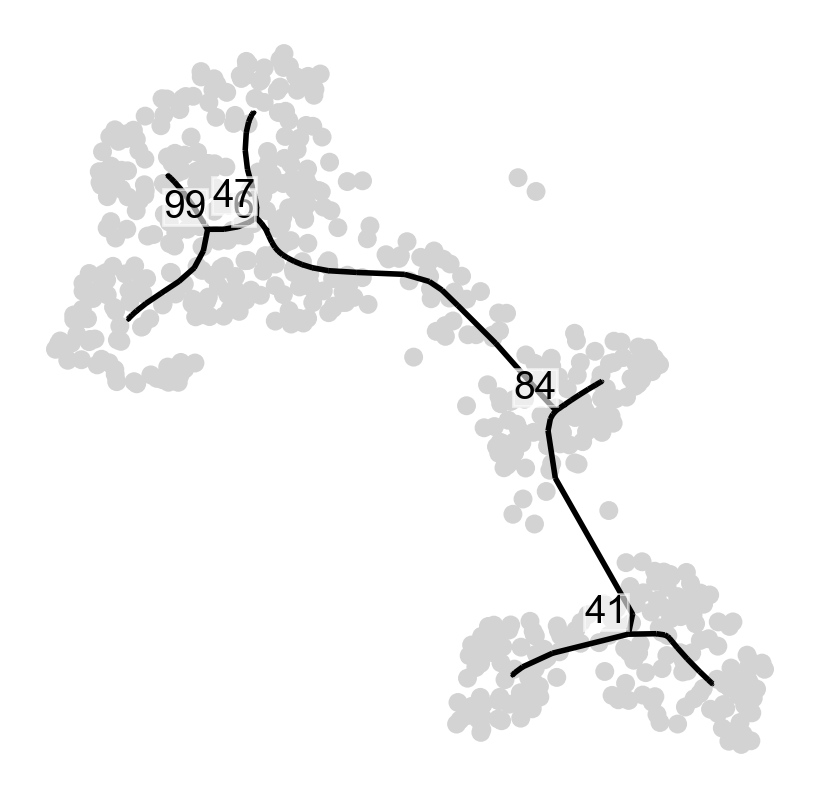

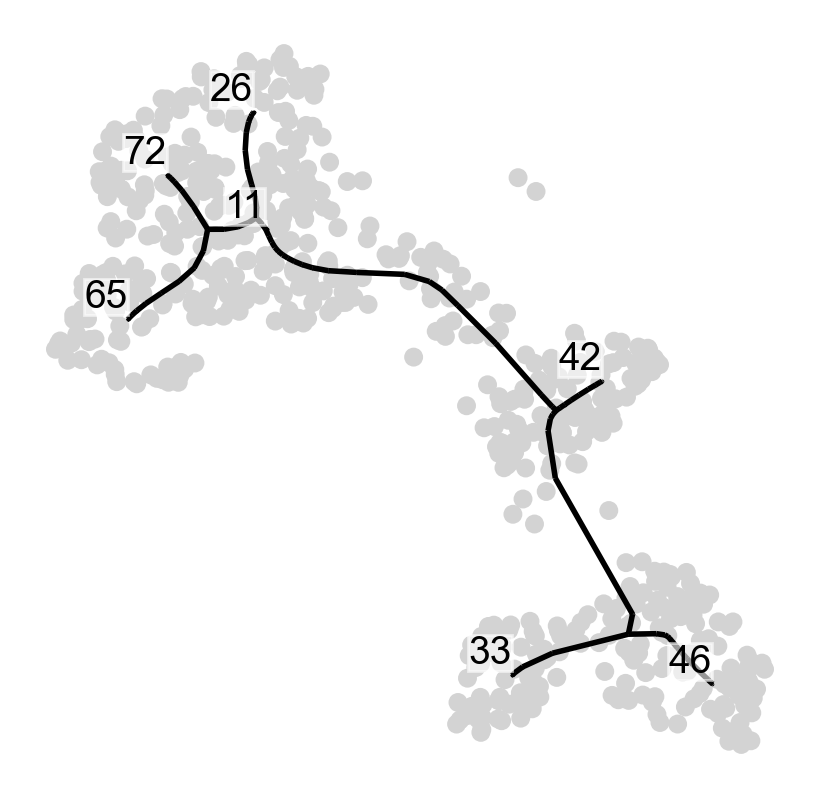

In [207]:
scf.tl.tree(adata_b,method="ppt",Nodes=100,use_rep="umap",
            device="cpu",seed=42,ppt_lambda=1,ppt_sigma=0.5,ppt_nsteps=1000)
scf.pl.graph(adata_b, forks=True, tips=False, size_nodes=.1)
scf.pl.graph(adata_b, forks=False, tips=True, size_nodes=.1)

    graph cleaned --> removed 33 principal points


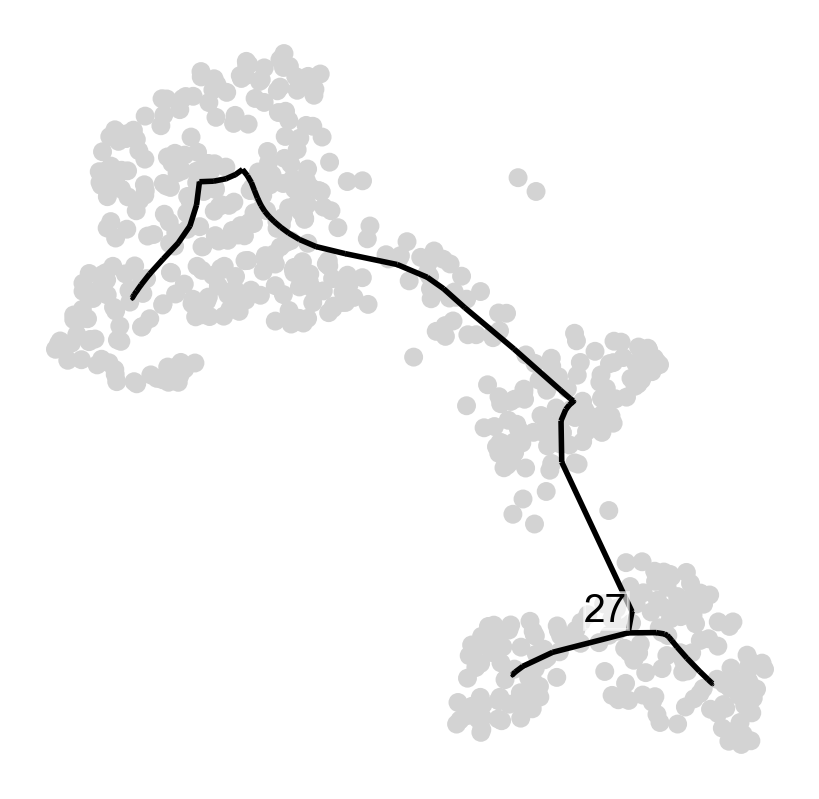

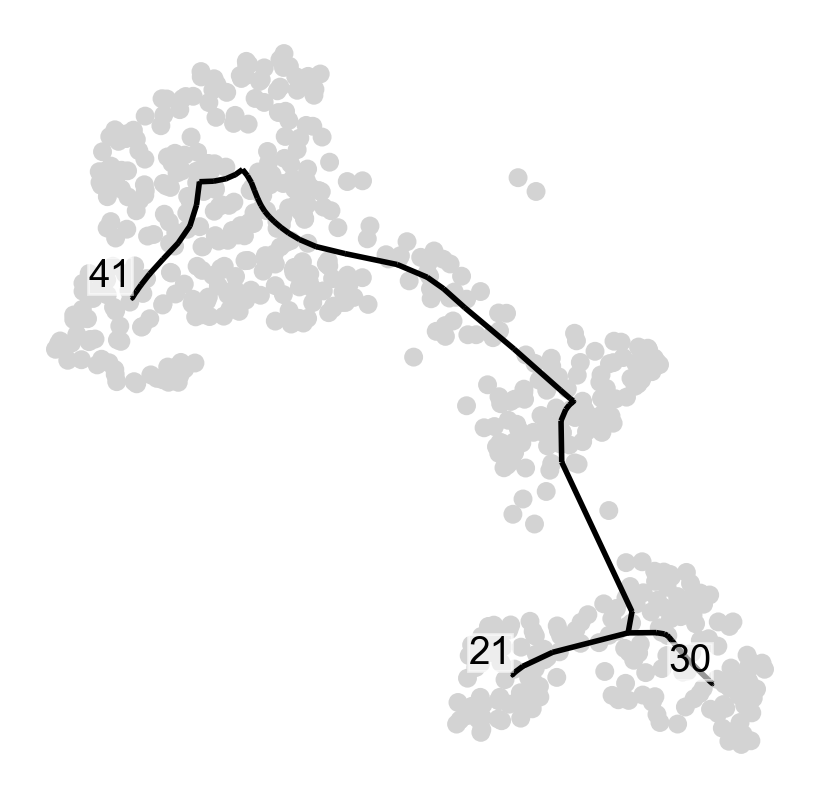

In [208]:
scf.tl.cleanup(adata_b, minbranchlength=0, leaves=[72,26,11,42])
scf.pl.graph(adata_b, forks=True, tips=False, size_nodes=.1)
scf.pl.graph(adata_b, forks=False, tips=True, size_nodes=.1)

In [209]:
scf.tl.root(adata_b,41)
scf.tl.pseudotime(adata_b,n_jobs=6,n_map=100,seed=42)

node 41 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.
projecting cells onto the principal graph
    mappings: 100%|██████████| 100/100 [00:03<00:00, 29.35it/s]
    finished (0:00:03) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


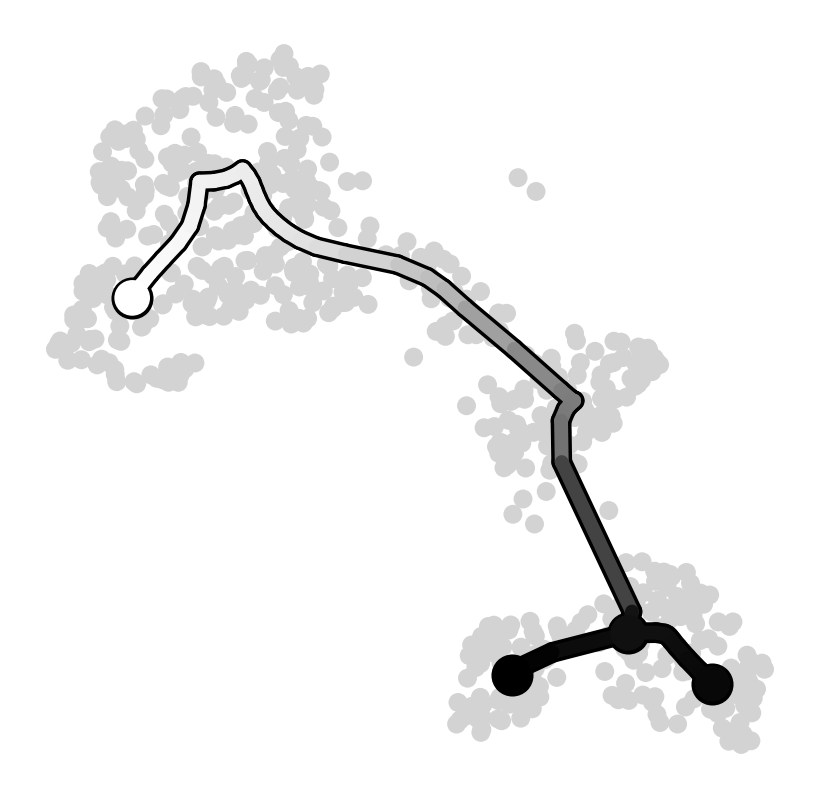

In [213]:
scf.pl.trajectory(adata_b, save='_pseudotime_branchB.pdf', cmap_seg='Greys')

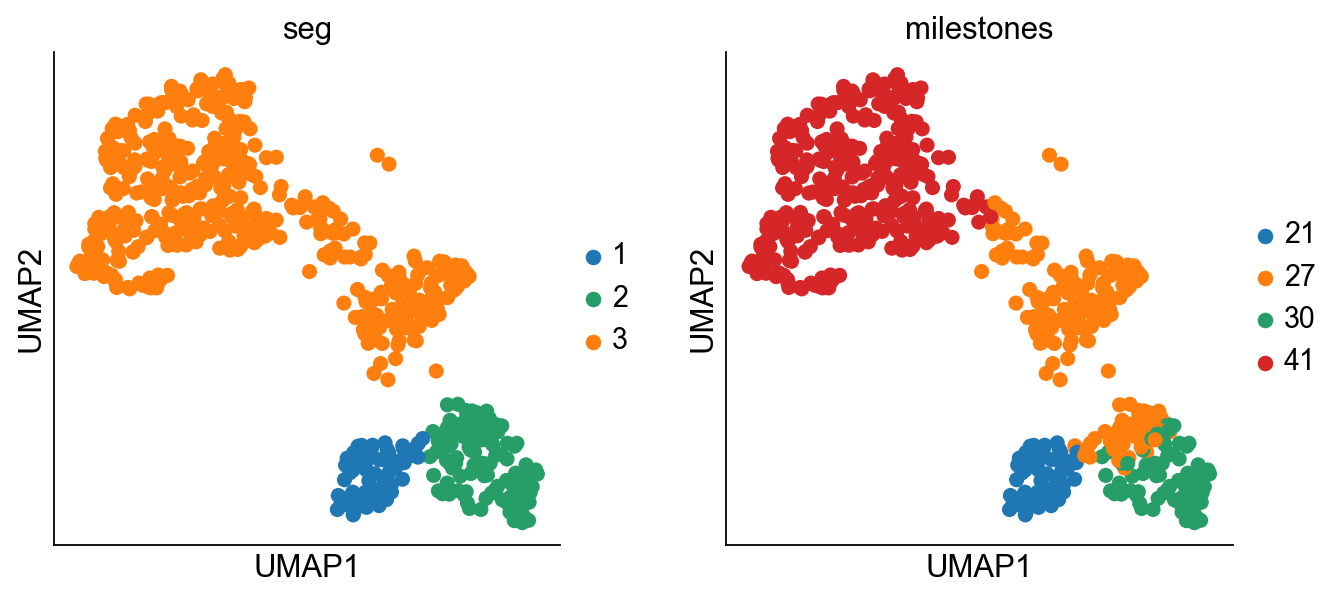

In [153]:
sc.pl.umap(adata_b,color=["seg","milestones"])

In [211]:
milestones_mapper = {'21': 'B1','27': 'BifA','30': 'B2','41': 'Root'}

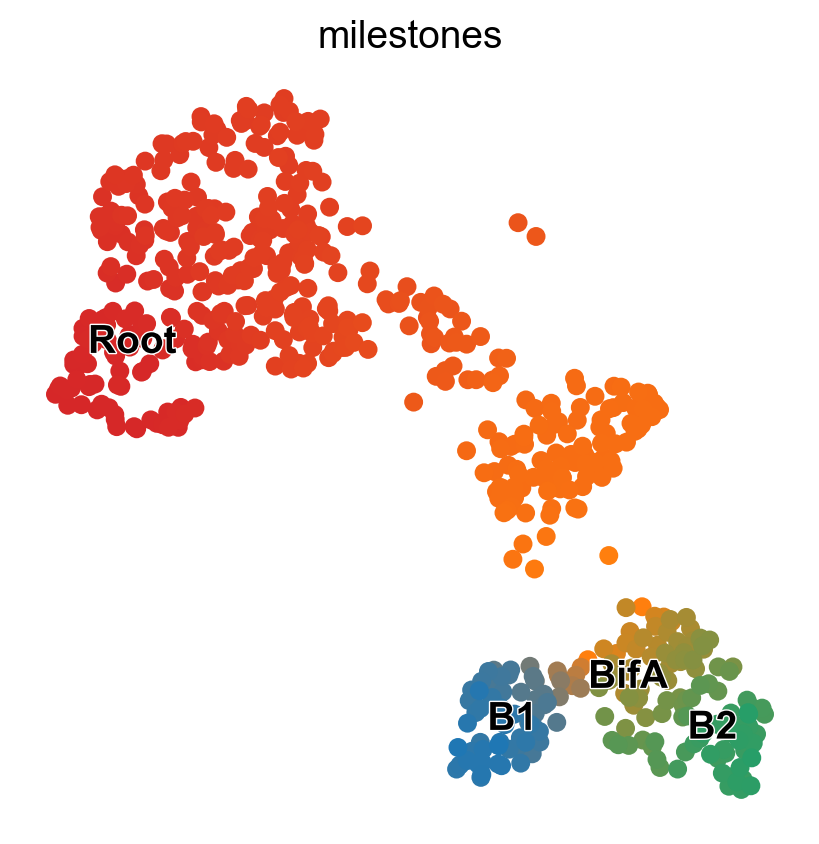

In [212]:
scf.tl.rename_milestones(adata_b,milestones_mapper)
scf.pl.milestones(adata_b, annotate=True, save='_milestones_branchB.pdf')

In [156]:
scf.tl.dendrogram(adata_b)
plt.close()

Generating dendrogram of tree
    finished (0:00:00) --> added 
    .obsm['X_dendro'], new embedding generated.
    .uns['dendro_segments'] tree segments used for plotting.


In [157]:
scf.tl.test_association(adata_b,n_jobs=6,fdr_cut=0.05,A_cut=0.0001)
scf.tl.fit(adata_b,n_jobs=6)

test features for association with the trajectory
    single mapping :   0%|          | 0/547 [00:00<?, ?it/s]

    single mapping : 100%|██████████| 547/547 [00:02<00:00, 229.52it/s]
    found 234 significant features (0:00:02) --> added
    .var['p_val'] values from statistical test.
    .var['fdr'] corrected values from multiple testing.
    .var['st'] proportion of mapping in which feature is significant.
    .var['A'] amplitue of change of tested feature.
    .var['signi'] feature is significantly changing along pseudotime.
    .uns['stat_assoc_list'] list of fitted features on the graph for all mappings.
fit features associated with the trajectory
    single mapping : 100%|██████████| 234/234 [00:02<00:00, 108.17it/s]
    finished (adata subsetted to keep only fitted features!) (0:00:02) --> added
    .layers['fitted'], fitted features on the trajectory for all mappings.
    .raw, unfiltered data.


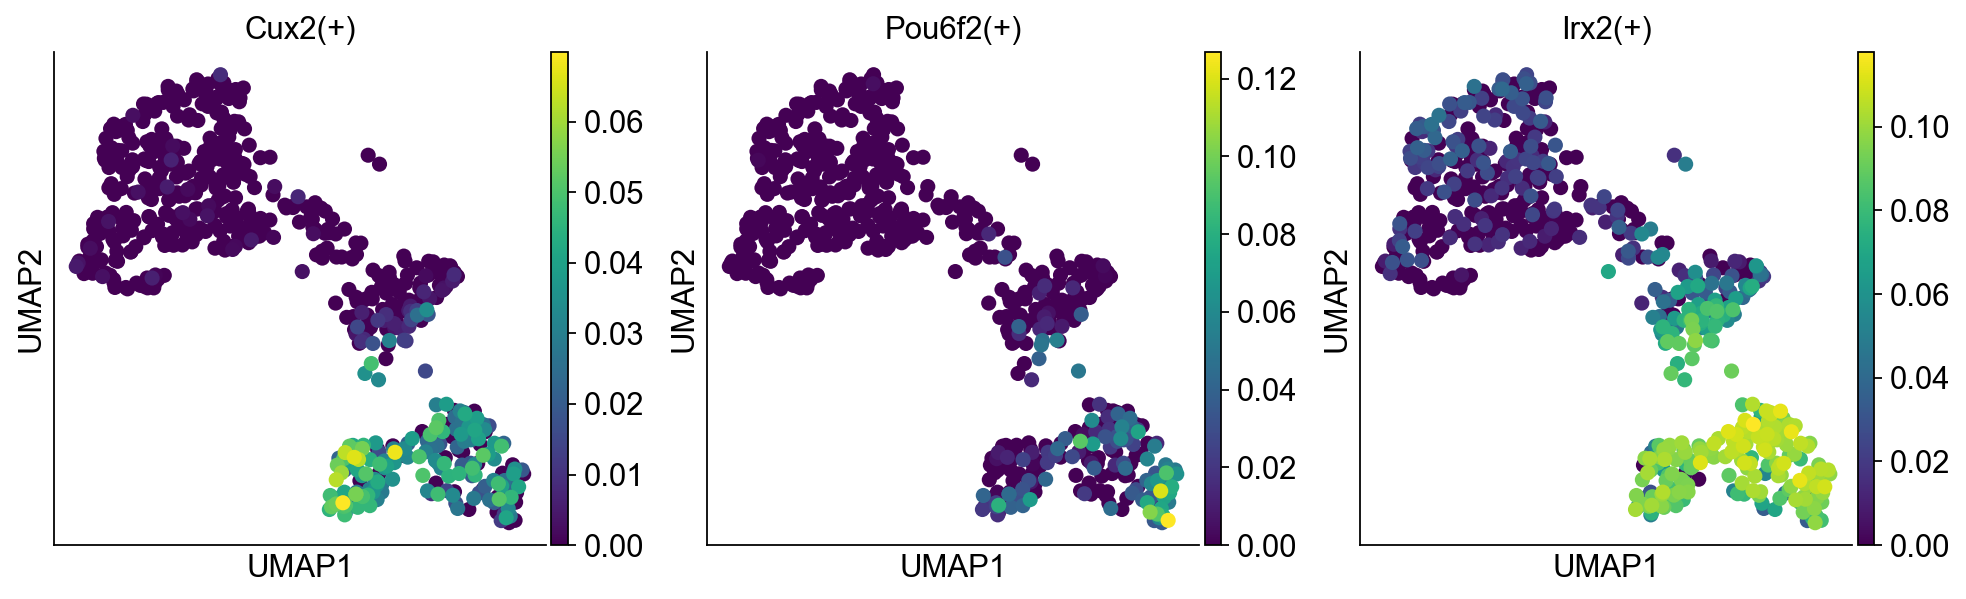

In [174]:
sc.pl.umap(adata_b,color=["Cux2(+)",'Pou6f2(+)',"Irx2(+)"], cmap='viridis')

In [159]:
milestones = ['B1','B2']

In [163]:
scf.tl.test_fork(adata_b,root_milestone="Root",milestones=milestones,n_jobs=6,rescale=True)

testing fork
    single mapping
    Differential expression: 100%|██████████| 234/234 [00:00<00:00, 342.81it/s]
    test for upregulation for each leave vs root
    upreg B2: 100%|██████████| 105/105 [00:06<00:00, 17.23it/s]  
    finished (0:00:08) --> added 
    .uns['Root->B1<>B2']['fork'], DataFrame with fork test results.


In [165]:
scf.tl.branch_specific(adata_b,root_milestone="Root",milestones=milestones,effect=0.00001)

    branch specific features: B1: 6, B2: 3
    finished --> updated 
    .uns['Root->B1<>B2']['fork'], DataFrame updated with additionnal 'branch' column.


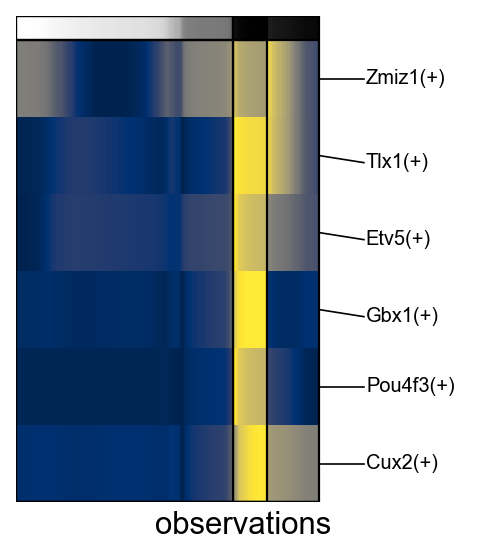

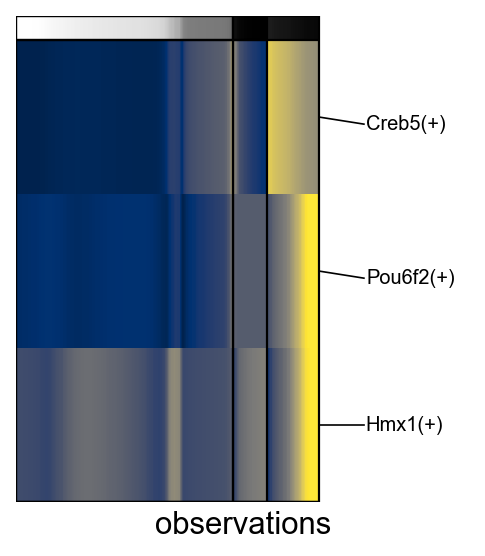

In [170]:
gg=[scf.pl.trends(adata_b,
                 root_milestone="Root",
                 milestones=milestones,
                 branch=m,
                 plot_emb=False,ordering="max",return_genes=True,feature_cmap='cividis', pseudo_cmap='Greys') for m in milestones]

In [ ]:
gg = gg[0].tolist() + gg[1].tolist()

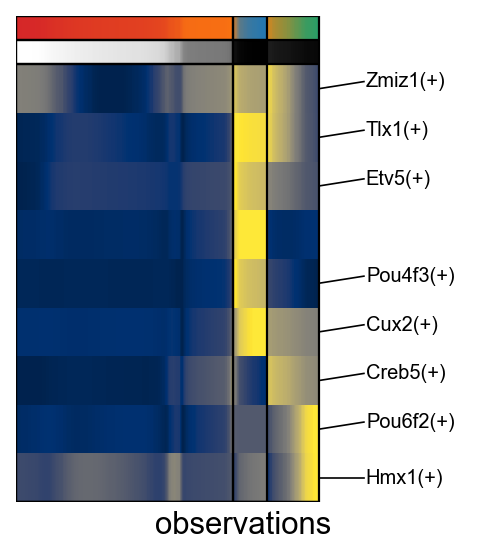

In [172]:
g=scf.pl.trends(adata_b,gg,figsize=(4,4),annot="milestones",n_features=8,
        plot_emb=False,ordering=None,return_genes=True,feature_cmap='cividis', pseudo_cmap='Greys')
plt.savefig("figures/gene_trend_branchB.pdf",dpi=300)

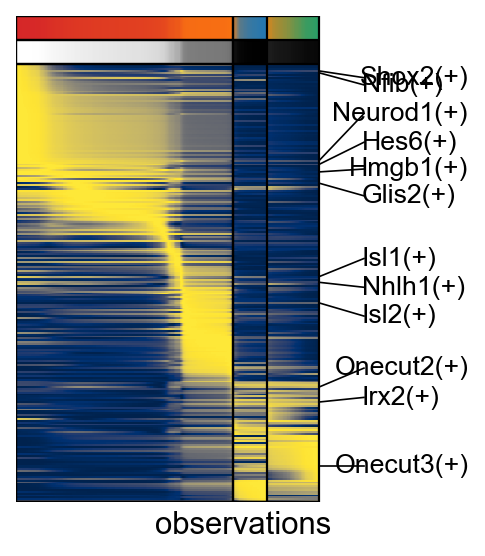

In [129]:
reg = scf.pl.trends(adata_b,root_milestone='Root',n_features=12,plot_emb=False,ordering="max",annot="milestones",
                    fig_heigth=20,ord_thre=.95,fontsize=12,return_genes=True,feature_cmap='cividis', pseudo_cmap='Greys')
# plt.savefig("./figures/top12_trends_branchB.pdf",bbox_inches='tight', dpi=300)

In [175]:
for g in ["Cux2(+)",'Pou6f2(+)',"Irx2(+)"]:
    ax=scf.pl.single_trend(adata_b,g,show=False,plot_emb='dendrogram',cmap_cells='cividis',cmap_seg='cividis', save=f"_{g.strip('(+)')}_trend_dendrogram_branchB.pdf")